# Data Preparation

In this notebook, we will prepare the data for training our machine learning model. Please go to `docs/2_data_preparation.md` to get insights

### Step 1: Import necessary libraries and load the dataset


In [1]:
import sys
from pathlib import Path
import importlib
from IPython.display import display
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.data_loader import DataLoader
from src.utils import data_prep
importlib.reload(data_prep)
from src.utils.data_prep import DataPrep
import pandas as pd
import seaborn as sns

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


### Step 2: Load the dataset


In [2]:
data_loader = DataLoader(INTERIM_DIR)
player_game_df = data_loader.load_data("player_game_data.csv")
display(player_game_df.head(10))


,game_id,episode,act,rank,date,agent,map,outcome,round_wins,round_losses,kills,deaths,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag,role
0,1,6,2,Placement,4/11/2023,Cypher,Ascent,Loss,5,13,8,15,4,0.5,-61,3,76,125,3,Sentinel
1,2,6,2,Placement,4/12/2023,Cypher,Icebox,Loss,4,13,3,15,2,0.2,-124,22,42,59,5,Sentinel
2,3,6,2,Placement,4/15/2023,KAY/O,Lotus,Win,13,4,7,12,7,0.6,-46,2,87,132,5,Initiator
3,4,6,2,Placement,4/15/2023,Brimstone,Ascent,Loss,9,13,18,12,10,1.5,23,14,137,230,2,Controller
4,5,6,2,Placement,4/15/2023,Cypher,Haven,Loss,1,13,6,14,3,0.4,-75,7,90,146,4,Sentinel
5,6,6,2,Silver 2,4/15/2023,KAY/O,Haven,Win,13,10,16,15,18,1.1,19,10,155,234,3,Initiator
6,7,6,2,Silver 2,4/15/2023,Cypher,Pearl,Loss,3,13,7,15,5,0.5,-43,11,112,145,4,Sentinel
7,8,6,2,Silver 2,4/15/2023,KAY/O,Icebox,Loss,4,13,8,15,4,0.5,-70,3,73,119,5,Initiator
8,9,6,2,Silver 2,4/16/2023,Cypher,Pearl,Loss,10,13,14,17,4,0.8,-32,9,99,160,4,Sentinel
9,10,6,2,Silver 2,4/16/2023,Phoenix,Fracture,Win,13,4,16,7,6,2.3,111,8,211,284,2,Duelist


In [3]:
# Define categorical columns for analysis
categorical_cols = [col for col in player_game_df.select_dtypes(include=['object', 'string']).columns.tolist()
                   if col not in ['player_id', 'game_id']]


### Step 3: Handle missing values or anomalies in the Categorical columns

**From data understanding, we found the following issues:**
- `rank` column has missing values
- `outcome` column has missing values (NaN) and invalid `'Unknown'` values
- `role` column has missing values
- `agent` column has `'UnknownAgent'` values

**Our approach:**
- Fill missing `rank` values with the **mode** (most frequent value) since it's categorical
- Fill missing/unknown `outcome` values by comparing `round_wins` vs `round_losses` for each match
- Fill missing `role` values with the **mode**
- Replace `'UnknownAgent'` with the **mode** of the agent column


In [4]:
summary = []

for col in categorical_cols:
    values = player_game_df[col].astype(str)

    summary.append({
        "column": col,
        "dtype": player_game_df[col].dtype,
        "missing_count": player_game_df[col].isnull().sum(),
        "missing_%": round(player_game_df[col].isnull().mean() * 100, 2),
        "unique_values": player_game_df[col].nunique(),
        "top_values": player_game_df[col].value_counts().head(5).to_dict(),
        "unknown_count": (values.str.lower().isin(["unknown", "unknownagent", "na", "n/a"])).sum()
    })

categorical_summary_df = pd.DataFrame(summary)
display(categorical_summary_df)


,column,dtype,missing_count,missing_%,unique_values,top_values,unknown_count
0,rank,object,15,1.16,14,"{'Ascendant 1': 195, 'Diamond 3': 169, 'Diamon...",0
1,date,object,0,0.00,320,"{'5/4/2023': 20, '5/22/2023': 15, '5/8/2023': ...",0
2,agent,object,0,0.00,12,"{'Cypher': 752, 'Killjoy': 250, 'Viper': 42, '...",25
3,map,object,0,0.00,11,"{'Ascent': 187, 'Lotus': 179, 'Bind': 170, 'Ha...",0
4,outcome,object,102,7.87,4,"{'Loss': 497, 'Win': 491, 'Draw': 106, 'Unknow...",100
5,role,object,25,1.93,4,"{'Sentinel': 1026, 'Controller': 135, 'Initiat...",0


#### Step 3A: Fill missing values in the `rank` column
Since `rank` is a categorical value, we use the **mode** (most frequent value) to fill missing values.


In [5]:
player_game_df = DataPrep.fill_with_mode(player_game_df, 'rank')


[rank] Missing before: 15 | Mode: Ascendant 1 | Missing after: 0


#### Step 3B: Fill invalid values in the `outcome` column
For each row where `outcome` is not `'Win'`, `'Loss'`, or `'Draw'`:
- If `round_wins > round_losses` → `'Win'`
- If `round_wins < round_losses` → `'Loss'`
- If `round_wins == round_losses` → `'Draw'`


In [6]:
player_game_df = DataPrep.fill_invalid_with_func(
    player_game_df,
    'outcome',
    ['Win', 'Loss', 'Draw'],
    DataPrep.determine_outcome
)


[outcome] Invalid before: 202 | Invalid after: 0


#### Step 3C: Fill missing values in the `role` column
Since `role` is a categorical value, we use the **mode** (most frequent value) to fill missing values.


In [7]:
player_game_df = DataPrep.fill_with_mode(player_game_df, 'role')


[role] Missing before: 25 | Mode: Sentinel | Missing after: 0


#### Step 3D: Fix `agent` column
Replace all occurrences of `'UnknownAgent'` with the mode with the most frequent agent of the specific row. This is a simple imputation strategy that assumes the most common agent is a reasonable guess for the missing value.


In [8]:
# Mode for agent name for role: Duelist
duelist_mode_agent = player_game_df[player_game_df['role'] == 'Duelist']['agent'].mode()[0]
# Mode for agent name for role: Controller
controller_mode_agent = player_game_df[player_game_df['role'] == 'Controller']['agent'].mode()[0]
# Mode for agent name for role: Sentinel
sentinel_mode_agent = player_game_df[player_game_df['role'] == 'Sentinel']['agent'].mode()[0]
# Mode for agent name for role: Initiator
initiator_mode_agent = player_game_df[player_game_df['role'] == 'Initiator']['agent'].mode()[0]

# Replace 'UnknownAgent' with the mode agent for each role
player_game_df.loc[(player_game_df['agent'] == 'UnknownAgent') & (player_game_df['role'] == 'Duelist'), 'agent'] = duelist_mode_agent
player_game_df.loc[(player_game_df['agent'] == 'UnknownAgent') & (player_game_df['role'] == 'Controller'), 'agent'] = controller_mode_agent
player_game_df.loc[(player_game_df['agent'] == 'UnknownAgent') & (player_game_df['role'] == 'Sentinel'), 'agent'] = sentinel_mode_agent
player_game_df.loc[(player_game_df['agent'] == 'UnknownAgent') & (player_game_df['role'] == 'Initiator'), 'agent'] = initiator_mode_agent

# Display if there are still any 'UnknownAgent' values
print("Remaining 'UnknownAgent' values:", (player_game_df['agent'] == 'UnknownAgent').sum())

Remaining 'UnknownAgent' values: 0


#### Step 3E: Verify categorical columns have no missing or invalid values

In [9]:
summary = []

for col in categorical_cols:
    values = player_game_df[col].astype(str)

    summary.append({
        "column": col,
        "dtype": player_game_df[col].dtype,
        "missing_count": player_game_df[col].isnull().sum(),
        "missing_%": round(player_game_df[col].isnull().mean() * 100, 2),
        "unique_values": player_game_df[col].nunique(),
        "top_values": player_game_df[col].value_counts().head(5).to_dict(),
        "unknown_count": (values.str.lower().isin(["unknown", "unknownagent", "na", "n/a"])).sum()
    })

categorical_summary_df = pd.DataFrame(summary)
display(categorical_summary_df)


,column,dtype,missing_count,missing_%,unique_values,top_values,unknown_count
0,rank,object,0,0.0,14,"{'Ascendant 1': 210, 'Diamond 3': 169, 'Diamon...",0
1,date,object,0,0.0,320,"{'5/4/2023': 20, '5/22/2023': 15, '5/8/2023': ...",0
2,agent,object,0,0.0,11,"{'Cypher': 777, 'Killjoy': 250, 'Viper': 42, '...",0
3,map,object,0,0.0,11,"{'Ascent': 187, 'Lotus': 179, 'Bind': 170, 'Ha...",0
4,outcome,object,0,0.0,3,"{'Win': 587, 'Loss': 585, 'Draw': 124}",0
5,role,object,0,0.0,4,"{'Sentinel': 1051, 'Controller': 135, 'Initiat...",0


### Step 4: Handle Missing Values or Anomalies in the Numeric Columns
**From data understanding, we found the issues, but we will select the columns relevant for us for calculation, or future model operation:**
- `round_wins` column has negative values which are invalid since wins cannot be negative
- `round_losses` column has negative values which are invalid since losses cannot be negative
- `kills` column has negative values which are invalid since kills cannot be negative
- `deaths` column has negative values which are invalid since deaths cannot be negative

#### Step 4A: Fix negative values in numeric columns
For each of the affected columns, we will replace negative values with 0 since it is not possible to have negative wins, losses, kills, or deaths.

In [10]:
# List of numeric columns to check for negative values
numeric_cols_to_fix = ['round_wins', 'round_losses', 'kills', 'deaths']

In [11]:
neg_report = []

for col in numeric_cols_to_fix:
    neg_count = (player_game_df[col] < 0).sum()
    neg_pct = round((player_game_df[col] < 0).mean() * 100, 2)

    neg_report.append({
        "column": col,
        "negative_count": neg_count,
        "negative_%": neg_pct,
        "min_value": player_game_df[col].min(),
        "max_value": player_game_df[col].max()
    })

neg_report_df = pd.DataFrame(neg_report)
display(neg_report_df)


,column,negative_count,negative_%,min_value,max_value
0,round_wins,42,3.24,-2,18
1,round_losses,32,2.47,-2,20
2,kills,42,3.24,-3,35
3,deaths,41,3.16,-3,26


#### Step 4B: Fix negative values in `round_wins` and `round_losses` based on the `outcome` column
Since `round_wins` and `round_losses` are directly related to the `outcome` of the game, we can use the `outcome` column to guide our imputation strategy for negative values in these two columns. We will apply the following logic:
- For rows where `outcome` is 'Win':
  - If `round_wins` is negative, replace it with the median `round_wins` value for all 'Win' outcomes.
  - If `round_losses` is negative, replace it with the median `round_losses` value for all 'Win' outcomes.
- For rows where `outcome` is 'Loss':
  - If `round_wins` is negative, replace it with the median `round_wins` value for all 'Loss' outcomes.
  - If `round_losses` is negative, replace it with the median `round_losses` value for all 'Loss' outcomes.
- For rows where `outcome` is 'Draw':
  - If `round_wins` is negative, replace it with the value of `round_losses` for that row (symmetry rule).
  - If `round_losses` is negative, replace it with the value of `round_wins` for that row (symmetry rule).
    - This is based on the assumption that in a draw, the number of wins and losses should be equal, so if one is negative, we can impute it with the other value.
- For any remaining negative values that do not fit the above logic (e.g., if both `round_wins` and `round_losses` are negative), we can impute them with the median values for their respective outcome groups or use a more advanced imputation strategy if necessary.


In [12]:
def fix_negative_by_outcome(df):
    df = df.copy()
    report = []

    # Precompute medians per outcome group (rounded to nearest int)
    medians = {
        "Win": {
            "round_wins": round(df.loc[df['outcome'] == 'Win', 'round_wins'].dropna().median()),
            "round_losses": round(df.loc[df['outcome'] == 'Win', 'round_losses'].dropna().median())
        },
        "Loss": {
            "round_wins": round(df.loc[df['outcome'] == 'Loss', 'round_wins'].dropna().median()),
            "round_losses": round(df.loc[df['outcome'] == 'Loss', 'round_losses'].dropna().median())
        },
        "Draw": {
            "round_wins": round(df.loc[df['outcome'] == 'Draw', 'round_wins'].dropna().median()),
            "round_losses": round(df.loc[df['outcome'] == 'Draw', 'round_losses'].dropna().median())
        }
    }

    # When both round_wins and round_losses are negative, we can directly impute both with the medians for that outcome group (or use symmetry for Draws)
    both_neg = (df['round_wins'] < 0) & (df['round_losses'] < 0)
    for outcome in ['Win', 'Loss', 'Draw']:
        mask = both_neg & (df['outcome'] == outcome)
        if mask.sum() > 0:
            df.loc[mask, 'round_wins'] = medians[outcome]['round_wins']
            df.loc[mask, 'round_losses'] = medians[outcome]['round_losses']
            method = "double-median" if outcome in ['Win', 'Loss'] else "draw-symmetric-median"
            report.append({
                "outcome": outcome,
                "column": "round_wins+round_losses",
                "fixed": int(mask.sum()),
                "method": method
            })

    # ---- Win ----
    mask_win = df['outcome'] == 'Win'
    neg_win_wins = mask_win & (df['round_wins'] < 0)
    neg_win_losses = mask_win & (df['round_losses'] < 0)
    if neg_win_wins.sum() > 0:
        df.loc[neg_win_wins, 'round_wins'] = medians['Win']['round_wins']
        report.append({"outcome": "Win", "column": "round_wins", "fixed": int(neg_win_wins.sum()), "method": "median"})
    if neg_win_losses.sum() > 0:
        df.loc[neg_win_losses, 'round_losses'] = medians['Win']['round_losses']
        report.append({"outcome": "Win", "column": "round_losses", "fixed": int(neg_win_losses.sum()), "method": "median"})

    # ---- Loss ----
    mask_loss = df['outcome'] == 'Loss'
    neg_loss_wins = mask_loss & (df['round_wins'] < 0)
    neg_loss_losses = mask_loss & (df['round_losses'] < 0)
    if neg_loss_wins.sum() > 0:
        df.loc[neg_loss_wins, 'round_wins'] = medians['Loss']['round_wins']
        report.append({"outcome": "Loss", "column": "round_wins", "fixed": int(neg_loss_wins.sum()), "method": "median"})
    if neg_loss_losses.sum() > 0:
        df.loc[neg_loss_losses, 'round_losses'] = medians['Loss']['round_losses']
        report.append({"outcome": "Loss", "column": "round_losses", "fixed": int(neg_loss_losses.sum()), "method": "median"})

    # ---- Draw (symmetry rule) ----
    mask_draw = df['outcome'] == 'Draw'
    neg_draw_wins = mask_draw & (df['round_wins'] < 0)
    neg_draw_losses = mask_draw & (df['round_losses'] < 0)
    if neg_draw_wins.sum() > 0:
        df.loc[neg_draw_wins, 'round_wins'] = df.loc[neg_draw_wins, 'round_losses']
        report.append({"outcome": "Draw", "column": "round_wins", "fixed": int(neg_draw_wins.sum()), "method": "copy round_losses"})
    if neg_draw_losses.sum() > 0:
        df.loc[neg_draw_losses, 'round_losses'] = df.loc[neg_draw_losses, 'round_wins']
        report.append({"outcome": "Draw", "column": "round_losses", "fixed": int(neg_draw_losses.sum()), "method": "copy round_wins"})

    return df, pd.DataFrame(report)

player_game_df, fix_report = fix_negative_by_outcome(player_game_df)
display(fix_report)

print("Negative values in round_wins after fix:", (player_game_df['round_wins'] < 0).sum())
print("Negative values in round_losses after fix:", (player_game_df['round_losses'] < 0).sum())


,outcome,column,fixed,method
0,Draw,round_wins+round_losses,1,draw-symmetric-median
1,Win,round_losses,22,median
2,Loss,round_wins,31,median
3,Draw,round_wins,10,copy round_losses
4,Draw,round_losses,9,copy round_wins


Negative values in round_wins after fix: 0
Negative values in round_losses after fix: 0


#### Step 4C: Verify consistency between `outcome` and `round_wins`/`round_losses`
After fixing the negative values, we should verify that the `outcome` column is consistent with the `round_wins` and `round_losses` columns. The expected logic is:
- If `round_wins > round_losses` → `outcome` should be 'Win'
- If `round_wins < round_losses` → `outcome` should be 'Loss'
- If `round_wins == round_losses` → `outcome` should be 'Draw'

In [13]:
# Function to verify consistency between round_wins/round_losses and outcome
def verify_outcome_consistency(df):
    df = df.copy()

    # Calculate outcome based on round_wins and round_losses
    df['calculated_outcome'] = df.apply(
        lambda row: 'Win' if row['round_wins'] > row['round_losses']
        else ('Loss' if row['round_wins'] < row['round_losses'] else 'Draw'),
        axis=1
    )

    # Calculate consistency %
    consistency = (df['outcome'] == df['calculated_outcome']).mean() * 100
    print(f"Outcome consistency after fix: {consistency:.2f}%")

    # Return dataframe for inspection
    return df

# Step 1: Verify and calculate mismatches
verified_df = verify_outcome_consistency(player_game_df)
mismatches = verified_df[verified_df['outcome'] != verified_df['calculated_outcome']]
print(f"Total mismatches before fix: {mismatches.shape[0]}")
display(mismatches)

# Step 2: Fix mismatches and report
if mismatches.shape[0] > 0:
    # Count mismatches per outcome type
    mismatch_counts = mismatches['outcome'].value_counts()
    print("Mismatches per outcome type before fix:")
    print(mismatch_counts)

    # Fix mismatches
    player_game_df.loc[player_game_df['outcome'] != verified_df['calculated_outcome'], 'outcome'] = \
        verified_df['calculated_outcome']

    print("Mismatches have been fixed.")
else:
    print("No mismatches found. Nothing to fix.")

# Step 3: Verify consistency again
final_verified_df = verify_outcome_consistency(player_game_df)


Outcome consistency after fix: 92.82%
Total mismatches before fix: 93


,game_id,episode,act,rank,date,agent,map,outcome,round_wins,round_losses,...,deaths,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag,role,calculated_outcome
1002,1533,6,3,Ascendant 1,6/11/2023,Astra,Split,Draw,4,9,...,20,6,-0.1,-8,61,155,32,2,Controller,Loss
1003,1268,9,3,Gold 1,2/16/2024,Omen,Bind,Draw,0,9,...,18,5,-0.3,-21,90,180,236,9,Controller,Loss
1008,1799,7,1,Gold 3,6/2/2023,Brimstone,Lotus,Draw,13,14,...,13,9,1.8,11,8,143,23,3,Controller,Loss
1010,1083,7,3,Platinum 3,4/4/2024,Omen,Abyss,Draw,13,14,...,14,0,-0.2,-50,98,56,71,10,Controller,Loss
1014,1084,8,2,Gold 3,12/21/2023,Brimstone,Abyss,Draw,10,11,...,13,9,2.0,-50,56,160,30,6,Controller,Loss
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1284,1891,7,3,Gold 3,02/22/2026,Brimstone,Split,Draw,10,3,...,15,8,2.3,35,87,7,58,7,Controller,Win
1286,1057,8,3,Diamond 1,02/16/2026,Brimstone,Breeze,Draw,14,8,...,11,5,0.9,-48,59,249,226,8,Controller,Win
1290,1777,7,2,Ascendant 2,11/4/2023,Astra,Icebox,Loss,8,5,...,5,10,0.2,18,91,50,37,2,Controller,Win
1291,1740,6,2,Diamond 2,11/11/2024,Brimstone,Breeze,Draw,6,8,...,7,10,1.0,17,77,13,266,7,Controller,Loss


Mismatches per outcome type before fix:
outcome
Draw    70
Loss    17
Win      6
Name: count, dtype: int64
Mismatches have been fixed.
Outcome consistency after fix: 100.00%


#### Step 4D: Fix negative values in `kills` and `deaths`, using the KD ratio if possible
For `kills` and `deaths`, we can use the KD ratio (kills/deaths) to guide our imputation strategy for negative values. We will apply the following logic:
- For rows where `kills` is negative and `deaths` is non-negative:
  - If `deaths` is greater than 0, we can impute `kills` using the median KD ratio for that player's role multiplied by the `deaths` value.
  - If `deaths` is 0, we can impute `kills` with the median `kills` value for that player's role, since a KD ratio cannot be calculated.
- For rows where `deaths` is negative and `kills` is non-negative:
  - If `kills` is greater than 0, we can impute `deaths` using the median KD ratio for that player's role divided by the `kills` value.
  - If `kills` is 0, we can impute `deaths` with the median `deaths` value for that player's role, since a KD ratio cannot be calculated.
- For rows where both `kills` and `deaths` are negative, we can impute both values using the median `kills` and `deaths` values for that player's role
- if kdr is negative or lies outside a reasonable range (e.g., less than 0 or greater than 10), we can impute it with the median KDR for that player's role
- Special Case: kills>0 and deaths=0
  - KDR in Valorant is usually treated as kills / 1 → i.e., KDR = kills
  - So if we have a case where kills is positive but deaths is zero, we can impute deaths as 0 and calculate KDR as kills / 1 = kills. This reflects the common practice in gaming statistics to avoid division by zero while still providing a meaningful KDR value.


In [14]:
def fix_kills_deaths(df):
    df = df.copy()

    # Step 1: Compute median kills, deaths, KDR per role
    role_stats = df.groupby('role').agg(
        median_kills=('kills', 'median'),
        median_deaths=('deaths', 'median')
    )
    role_stats['median_kdr'] = role_stats['median_kills'] / role_stats['median_deaths'].replace(0, 1)

    # Step 2: Identify negative kills or deaths
    inconsistencies = df[(df['kills'] < 0) | (df['deaths'] < 0)]
    print(f"Total rows with negative kills or deaths before fix: {inconsistencies.shape[0]}")
    display(inconsistencies)

    # Step 3: Fix negative kills
    for role, stats in role_stats.iterrows():
        mask = (df['role'] == role) & (df['kills'] < 0)
        # deaths > 0 → use median KDR * deaths
        mask_deaths_positive = mask & (df['deaths'] > 0)
        df.loc[mask_deaths_positive, 'kills'] = round(stats['median_kdr'] * df.loc[mask_deaths_positive, 'deaths'])

        # deaths == 0 → use median kills
        mask_deaths_zero = mask & (df['deaths'] == 0)
        df.loc[mask_deaths_zero, 'kills'] = stats['median_kills']

    # Step 4: Fix negative deaths
    for role, stats in role_stats.iterrows():
        mask = (df['role'] == role) & (df['deaths'] < 0)
        # kills > 0 → deaths = kills / median KDR
        mask_kills_positive = mask & (df['kills'] > 0)
        df.loc[mask_kills_positive, 'deaths'] = round(df.loc[mask_kills_positive, 'kills'] / stats['median_kdr'])

        # kills == 0 → use median deaths
        mask_kills_zero = mask & (df['kills'] == 0)
        df.loc[mask_kills_zero, 'deaths'] = stats['median_deaths']

    # Step 5: Fix rows where both kills and deaths are negative
    for role, stats in role_stats.iterrows():
        mask = (df['role'] == role) & (df['kills'] < 0) & (df['deaths'] < 0)
        df.loc[mask, 'kills'] = stats['median_kills']
        df.loc[mask, 'deaths'] = stats['median_deaths']

    # Step 6: Compute KDR (kills / deaths) and handle special case kills>0 & deaths=0
    df['kdr'] = df['kills'] / df['deaths'].replace(0, 1)

    # Step 7: Show any remaining negative values (should be zero now)
    inconsistencies_after = df[(df['kills'] < 0) | (df['deaths'] < 0)]
    print(f"Total rows with negative kills or deaths after fix: {inconsistencies_after.shape[0]}")
    display(inconsistencies_after)

    return df

# Apply the fix
player_game_df = fix_kills_deaths(player_game_df)


Total rows with negative kills or deaths before fix: 78


,game_id,episode,act,rank,date,agent,map,outcome,round_wins,round_losses,kills,deaths,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag,role
1000,1592,7,2,Gold 3,02/18/2026,Fade,Sunset,Loss,0,4,-2,2,0,2.5,11,80,172,66,10,Initiator
1001,1853,9,1,Silver 3,9/27/2024,Killjoy,Lotus,Win,14,6,3,-1,5,0.1,47,89,203,73,10,Sentinel
1005,1653,6,2,Diamond 2,5/31/2024,Omen,Haven,Win,10,5,16,-1,9,1.2,13,31,231,87,3,Controller
1009,1959,6,3,Gold 1,6/25/2024,Brimstone,Breeze,Loss,13,14,17,-1,10,0.9,-39,63,224,147,4,Controller
1017,1331,6,2,Diamond 2,6/6/2023,Phoenix,Lotus,Draw,0,0,10,-1,3,1.7,-24,96,229,234,2,Duelist
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1278,1947,6,2,Ascendant 1,6/25/2023,Cypher,Sunset,Draw,14,14,1,-2,3,1.8,33,89,25,196,3,Sentinel
1286,1057,8,3,Diamond 1,02/16/2026,Brimstone,Breeze,Win,14,8,-1,11,5,0.9,-48,59,249,226,8,Controller
1288,1812,6,1,Diamond 2,7/24/2024,Omen,Ascent,Win,14,12,17,-3,4,0.8,-21,85,115,261,3,Controller
1291,1740,6,2,Diamond 2,11/11/2024,Brimstone,Breeze,Loss,6,8,-2,7,10,1.0,17,77,13,266,7,Controller


Total rows with negative kills or deaths after fix: 0


,game_id,episode,act,rank,date,agent,map,outcome,round_wins,round_losses,kills,deaths,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag,role


### Step 6: Finalize and Save Cleaned Dataset

In [15]:
# We will now save the cleaned dataset to the processed directory for use in modeling and analysis.
processed_file_path = INTERIM_DIR / "player_game_data_cleaned.csv"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
player_game_df.to_csv(processed_file_path, index=False)
print(f"Cleaned dataset saved to: {processed_file_path}")

Cleaned dataset saved to: C:\Personel\Github\Valorant_Player_Performance_Predictor\data\interim\player_game_data_cleaned.csv


### Step 7 : Feature Engineering

Initially, when we tried to extract features directly from `acs` (Average Combat Score), we encountered challenges due to the high variability in ACS values between matches and players. Because ACS can fluctuate significantly depending on game dynamics, using it as a continuous variable resulted in unpredictable feature distributions and low interpretability.

So what we will do is apply this binning approach to the ACS values in our dataset, assigning a `Performance` grade to each player based on their ACS. This involves:
1. Defining the ACS bins and corresponding performance grades.
2. Using those bins to categorize each player's ACS.
3. Adding a new `Performance` column to the dataset for use in further modeling and analysis.


Ref:
1. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
2. https://www.planmyleave.com/BlogDetail/269/why-should-you-bin-numerical-columns-in-machine-learning/0/Blog#:~:text=Binned%20features%20are%20easier%20to,a%20loss%20of%20valuable%20information.

In [16]:
import pandas as pd

# Load cleaned data
player_game_df = pd.read_csv(processed_file_path)

# Step 1: Add win_loss_margin and performance (two extra derived columns)
bin_width = 40
margin_weight = 10

def calculate_performance(acs, margin, bin_width=40, margin_weight=10):
    combined_score = acs + (margin_weight * margin)
    return int(combined_score // bin_width) + 1

player_game_df['win_loss_margin'] = player_game_df['round_wins'] - player_game_df['round_losses']

player_game_df['performance'] = player_game_df.apply(
    lambda row: calculate_performance(row['acs'], row['win_loss_margin'], bin_width, margin_weight),
    axis=1
)

display(player_game_df[['acs', 'win_loss_margin', 'performance']].head(10))

# Step 2: Keep all original features + win_loss_margin; no encoding
target = 'performance'
drop_cols = [target, 'win_loss_margin']  # exclude target and the new column we use as feature only in X
feature_cols = [c for c in player_game_df.columns if c != target]

X = player_game_df[feature_cols].copy()
y = player_game_df[target]



,acs,win_loss_margin,performance
0,125,-8,2
1,59,-9,0
2,132,9,6
3,230,-4,5
4,146,-12,1
5,234,3,7
6,145,-10,2
7,119,-9,1
8,160,-3,4
9,284,9,10


### Step 8 : Feature Correlation


Correlation of numeric features with target ('performance'):



,performance
acs,0.787031
win_loss_margin,0.686723
avg_dmg_delta,0.673601
round_wins,0.601351
kills,0.505815
avg_dmg,0.386703
kdr,0.280792
assists,0.064134
act,-0.020146
episode,-0.022168


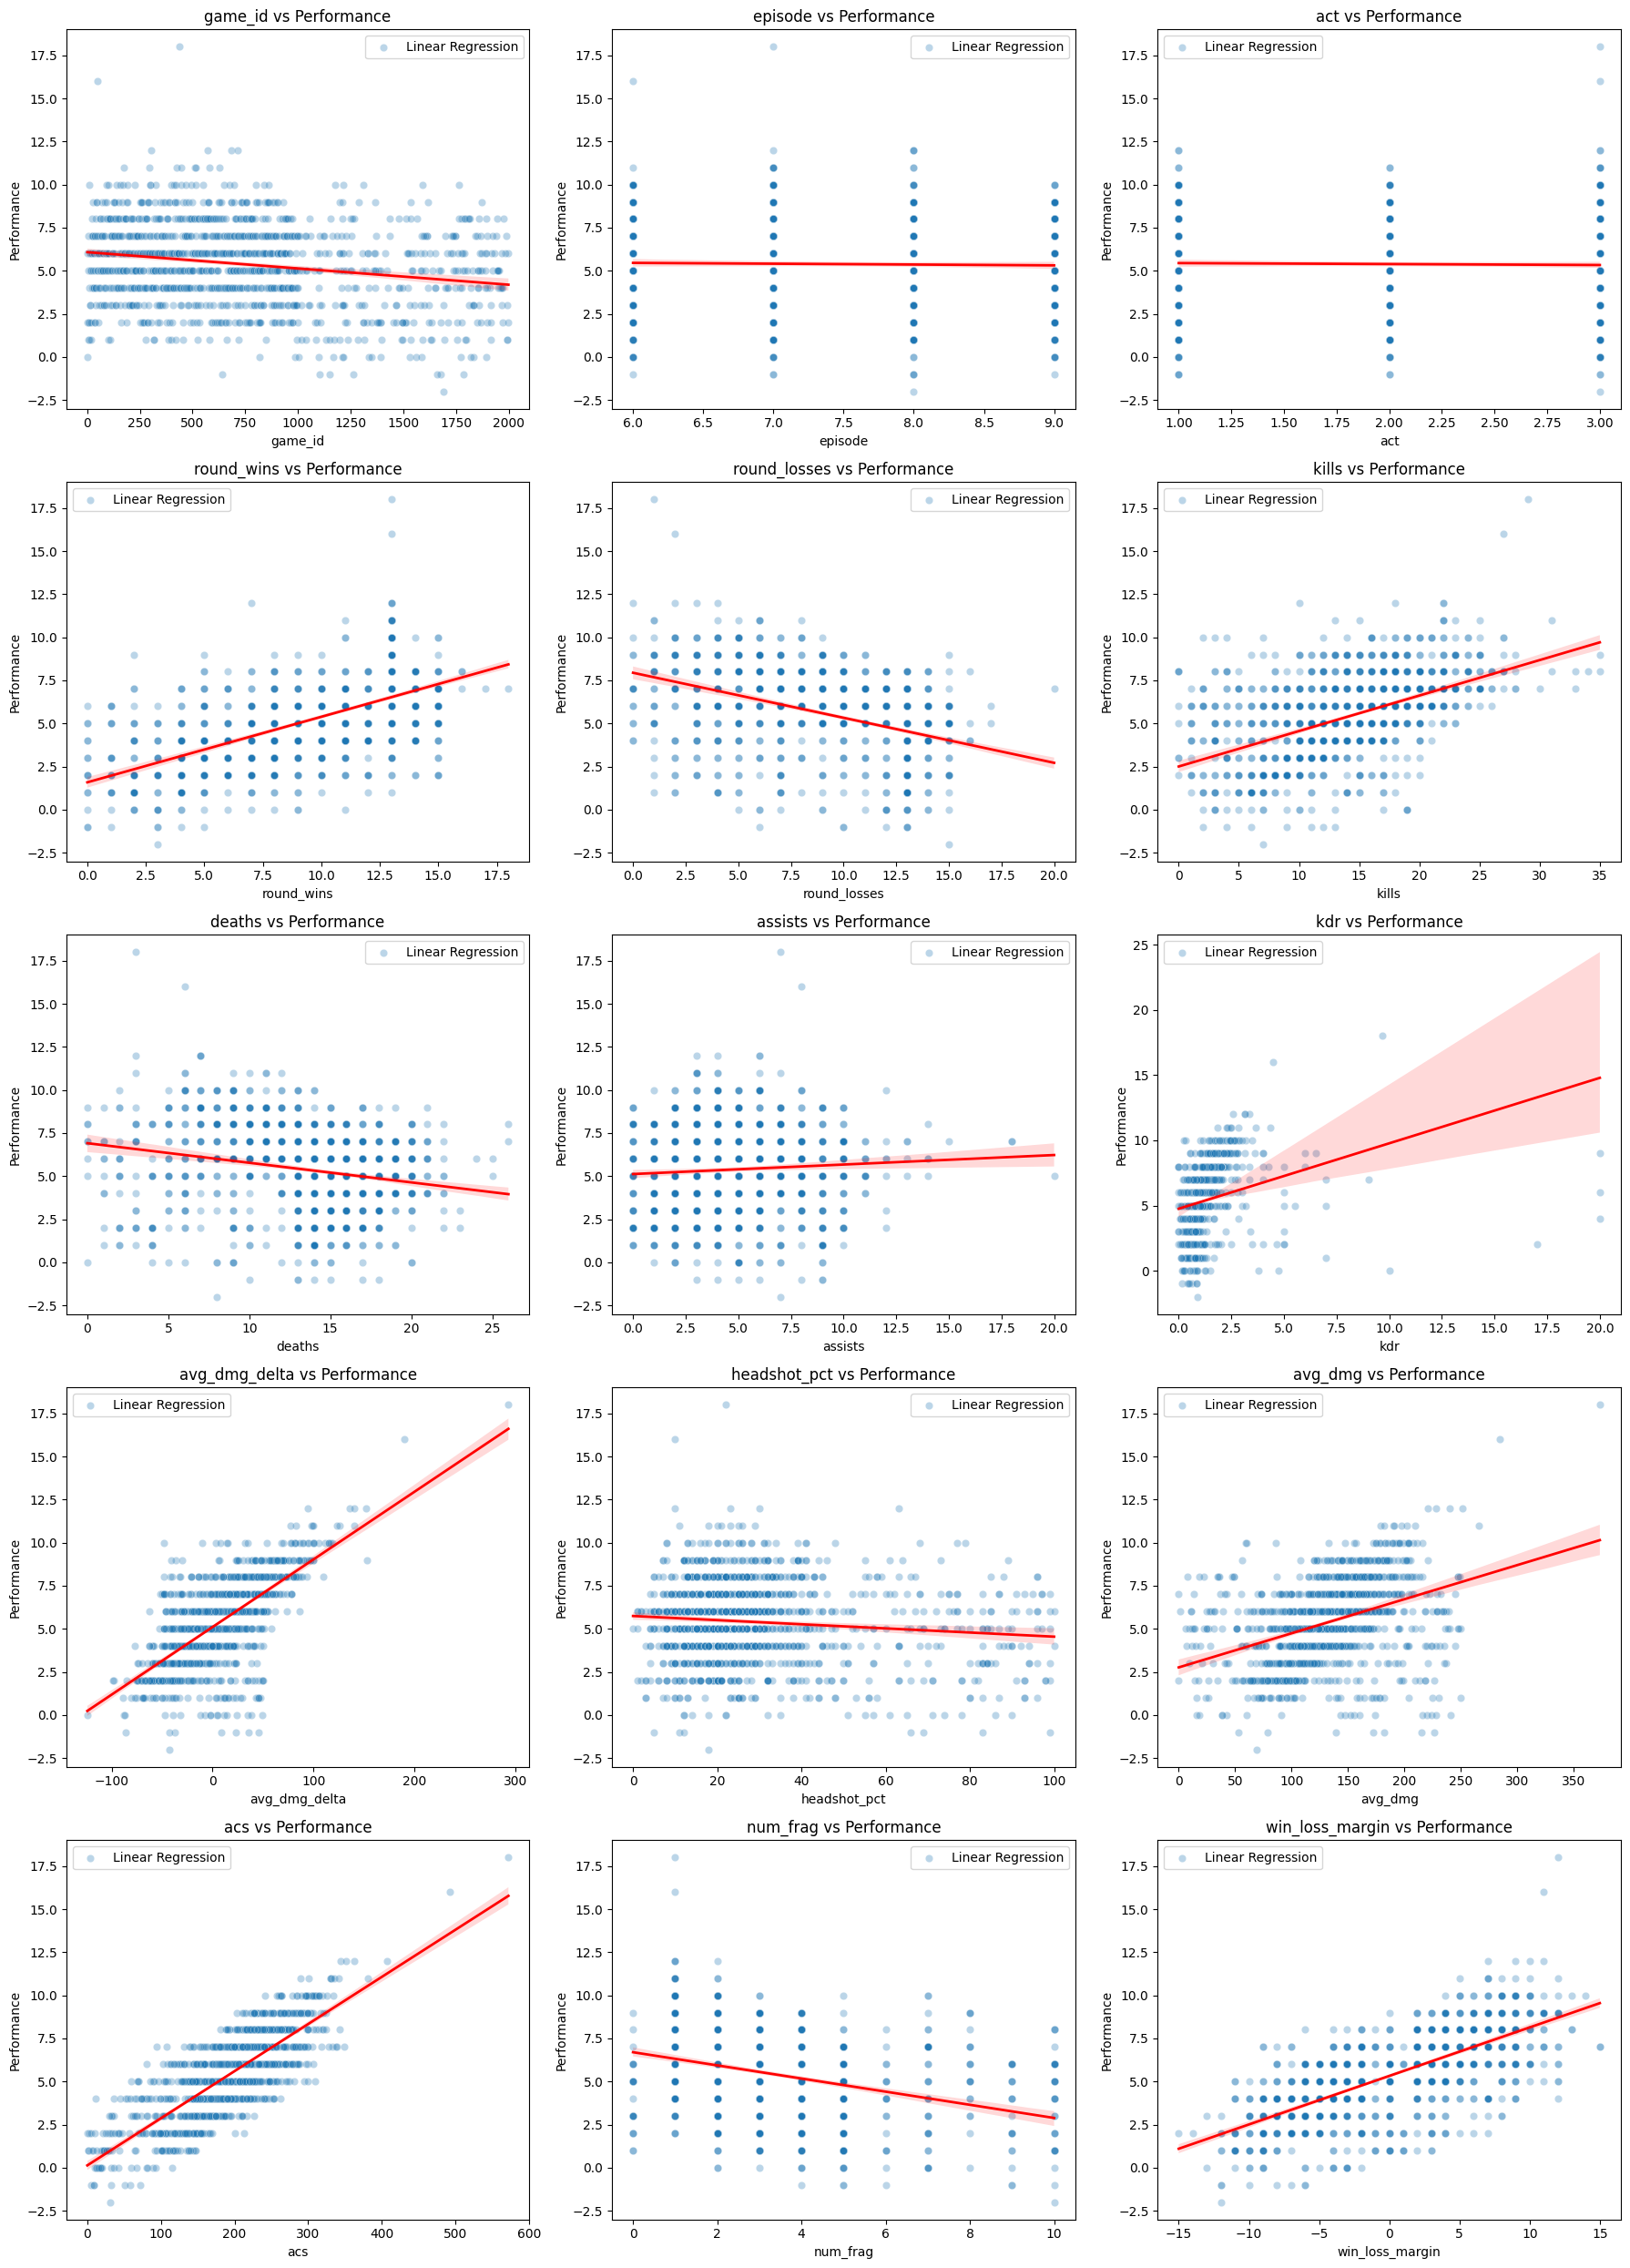

In [17]:
# Correlation analysis: only numeric columns (categorical are kept as strings)
feature_data = X.select_dtypes(include='number').copy()
feature_data['performance'] = y.values

corr = feature_data.corr()

target_corr = corr['performance'].drop('performance').sort_values(ascending=False)
print("\nCorrelation of numeric features with target ('performance'):\n")
display(target_corr.to_frame().style.background_gradient(cmap='viridis'))

features = list(feature_data.columns)
features.remove('performance')
num_features = len(features)
cols = 3
rows = (num_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes[idx]
    sns.scatterplot(x=feature_data[feature], y=feature_data['performance'], alpha=0.3, ax=ax)
    sns.regplot(x=feature_data[feature], y=feature_data['performance'],
                scatter=False, color='red', line_kws={'label': 'Linear Regression', 'lw': 2}, ax=ax)
    ax.set_xlabel(feature)
    ax.set_ylabel('Performance')
    ax.set_title(f"{feature} vs Performance")
    ax.legend(['Linear Regression'])

for idx in range(num_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


### Step 9 : Split data into training and testing sets 
(https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). 

- Shuffle the data to ensure that the original ordering does not bias the split.
- Set a random seed (random_state) for reproducibility.
- For regression tasks with continuous targets, a simple random split can lead to train and test sets with slightly different target distributions, especially for skewed or multimodal targets. This can bias model evaluation. To avoid this, we create fine-grained bins of the target and stratify the split based on these bins. Please check the second link to get more information.

Train shape: (1034, 21)
Test shape: (259, 21)
Train set saved to: C:\Personel\Github\Valorant_Player_Performance_Predictor\data\processed\train\train.csv
Test set saved  to: C:\Personel\Github\Valorant_Player_Performance_Predictor\data\processed\test\test.csv


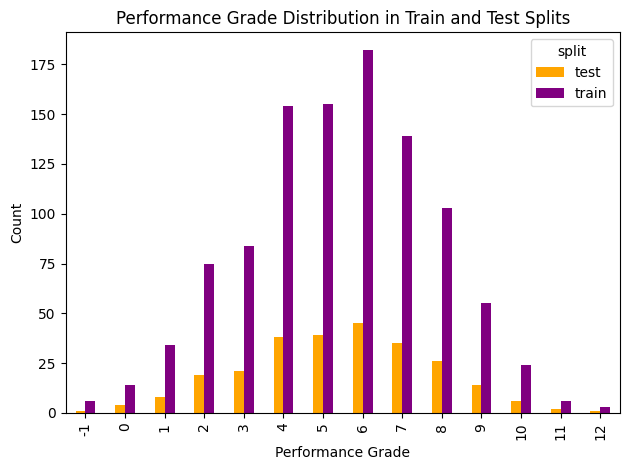

In [18]:


# Filter rare grades for proper stratification
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index
X = X[y.isin(valid_classes)]
y = y[y.isin(valid_classes)]

# Stratified split
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

train_df = x_train.copy()
train_df['performance'] = y_train.values
test_df = x_test.copy()
test_df['performance'] = y_test.values

# Save to processed/train and processed/test
train_dir = PROCESSED_DIR / "train"
test_dir = PROCESSED_DIR / "test"
train_dir.mkdir(parents=True, exist_ok=True)
test_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(train_dir / "train.csv", index=False)
test_df.to_csv(test_dir / "test.csv", index=False)
print(f"Train set saved to: {train_dir / 'train.csv'}")
print(f"Test set saved  to: {test_dir / 'test.csv'}")

# Visualization for validation
merged_df = pd.concat([
    train_df.assign(split='train'),
    test_df.assign(split='test')
], ignore_index=True)
split_counts = merged_df.groupby(['split', 'performance']).size().reset_index(name='count')
pivot = split_counts.pivot(index='performance', columns='split', values='count').fillna(0)

pivot.plot.bar(color={'train': 'purple', 'test': 'orange'})
plt.title('Performance Grade Distribution in Train and Test Splits')
plt.xlabel('Performance Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
